# 📊 Chart Pipeline — Build It From Scratch

**Workshop goal:** implement each stage of the chart-understanding pipeline yourself.
Pre-trained model weights are provided automatically. You write the logic that uses them.

### What you will build
| Step | Task |
|------|------|
| STEP 4 | Render PDF pages to images (PyMuPDF) |
| STEP 5 | Detect chart regions with YOLO |
| STEP 6 | Classify each chart type |
| STEP 7 | Extract text with PaddleOCR |
| STEP 9 | Label OCR boxes with Qwen2.5-VL |
| STEP 11 | Run the full bar + line pipeline end-to-end |

**Rules:**
- Do **not** skip ahead — each step's output feeds the next.
- `# TODO` marks every line you must write.
- Run the cell when you think it's correct; read the output before moving on.
- The PARAMS cell (STEP 0) is pre-filled — change values to experiment.


## STEP 1 — Install PaddleOCR (4 cells, in order)

PaddleOCR's install is fussy in Colab — these 4 cells are the known-good sequence.

**Run them top to bottom:**
1. First install of PaddlePaddle (CPU) + PaddleOCR
2. **Restart the Colab session** (Runtime → Restart session) after Cell 1 finishes
3. After restart, run Cells 2, 3, 4 in order. Cell 4 prints `PaddleOCR loaded successfully.` and creates the global `ocr` object the rest of the notebook uses.

> Don't merge or skip any of these — the restart between Cell 1 and Cell 2 is required to clear the conflicting wheel state.

In [1]:
# ==== PADDLEOCR CPU INSTALL : SAFE COLAB BLOCK ====

!python -V
!pip uninstall -y paddlepaddle paddlepaddle-gpu paddleocr paddlex || true
!pip install -U pip setuptools wheel

# Official Paddle CPU wheel index shown in PaddleOCR quick start
!python -m pip install paddlepaddle==3.2.0 -i https://www.paddlepaddle.org.cn/packages/stable/cpu/

# Install PaddleOCR after PaddlePaddle
!python -m pip install paddleocr

#RESTART THE SESSION

Python 3.12.13
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 36.6 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.2.0
    Uninstalling setuptools-75.2.0:
      Successfully uninstalled setuptools-75.2.0
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.


Looking in indexes: https://www.paddlepaddle.org.cn/packages/stable/cpu/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/189.0 MB 78.5 kB/s eta 0:39:55
ERROR: Operation cancelled by user
^C
^C


In [1]:
# After Restarting the Session Run From Here
#==== CLEAN CONFLICTS ====

!pip uninstall -y \
  langchain \
  langchain-core \
  langchain-community \
  langchain-text-splitters \
  langsmith \
  paddleocr \
  paddlex \
  paddlepaddle \
  paddlepaddle-gpu

Found existing installation: langchain 1.2.15
Uninstalling langchain-1.2.15:
  Successfully uninstalled langchain-1.2.15
Found existing installation: langchain-core 1.3.1
Uninstalling langchain-core-1.3.1:
  Successfully uninstalled langchain-core-1.3.1
Found existing installation: langsmith 0.7.34
Uninstalling langsmith-0.7.34:
  Successfully uninstalled langsmith-0.7.34


In [2]:
# ==== INSTALL PADDLE OCR (CPU SAFE) ====

!python -V
!pip install -U pip setuptools wheel

# Official Paddle CPU install
!python -m pip install paddlepaddle==3.2.0 -i https://www.paddlepaddle.org.cn/packages/stable/cpu/

# Then PaddleOCR
!python -m pip install paddleocr==3.4.0

Python 3.12.13
Looking in indexes: https://www.paddlepaddle.org.cn/packages/stable/cpu/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.0/189.0 MB 7.4 MB/s  0:00:33
  Attempting uninstall: opt_einsum
    Found existing installation: opt_einsum 3.4.0
    Uninstalling opt_einsum-3.4.0:
      Successfully uninstalled opt_einsum-3.4.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [paddlepaddle]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 14.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 16.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 60.3 MB/s  0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 155.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 156.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 119.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 57.4 MB/s  0:00:00
  Attempting uninstall: PyYAML
    Found existing installation: PyYAML 

In [3]:
import os
os.environ["PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK"] = "True"

import paddle
print("Paddle version:", paddle.__version__)
print("CUDA:", paddle.is_compiled_with_cuda())

from paddleocr import PaddleOCR

ocr = PaddleOCR(
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False
)

print("PaddleOCR loaded successfully.")

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


Paddle version: 3.2.0
CUDA: False


Connectivity check to the model hoster has been skipped because `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` is enabled.
Creating model: ('PP-OCRv5_server_det', None)
Using official model (PP-OCRv5_server_det), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv5_server_det`.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('PP-OCRv5_server_rec', None)
Using official model (PP-OCRv5_server_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv5_server_rec`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

PaddleOCR loaded successfully.


## STEP 2 — Install the remaining dependencies

Qwen2.5-VL, YOLO (ultralytics), PyMuPDF, gdown. Safe to run after the PaddleOCR session restart.

In [4]:
# ==== Qwen2.5-VL ====
!pip install -q transformers accelerate qwen-vl-utils

# ==== YOLO + PDF + Drive download ====
!pip install -q ultralytics opencv-python pillow matplotlib pandas tqdm
!pip install -q pymupdf gdown

print("✅ Other dependencies installed")
!nvidia-smi | head -10

✅ Other dependencies installed
Mon May 25 10:13:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |


## STEP 3 — Download demo bundle (weights + sample papers)

Downloads the model-weights zip from Google Drive and extracts it to `/content/chart_demo/`.
This contains all YOLO weights used by the pipeline plus 5 sample PDF papers in `sample_papers/`.

In [5]:
from pathlib import Path
import zipfile, shutil

ROOT = Path("/content/chart_demo")
ZIP_PATH = Path("/content/chart_bar_line_qwen_demo_bundle.zip")

# Demo bundle Google Drive ID (replace with your own if you re-package)
DRIVE_FILE_ID = "185upEGS0nI_IjGxoneglgjIfKBGvRNnU"

if ROOT.exists():
    shutil.rmtree(ROOT)
ROOT.mkdir(parents=True, exist_ok=True)

!gdown --id "$DRIVE_FILE_ID" -O "$ZIP_PATH"

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(ROOT)

# Normalize any Windows-style backslash paths inside the zip
for p in list(ROOT.rglob("*")):
    if p.is_file() and "\\" in p.name:
        parts = p.name.split("\\")
        new_path = p.parent.joinpath(*parts)
        new_path.parent.mkdir(parents=True, exist_ok=True)
        if not new_path.exists():
            shutil.move(str(p), str(new_path))

print("✅ Extracted to:", ROOT)
for p in sorted(ROOT.iterdir())[:15]:
    print(" -", p.name)

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=185upEGS0nI_IjGxoneglgjIfKBGvRNnU
From (redirected): https://drive.google.com/uc?id=185upEGS0nI_IjGxoneglgjIfKBGvRNnU&confirm=t&uuid=eaa9cec9-4fa0-4463-961d-3a5951def401
To: /content/chart_bar_line_qwen_demo_bundle.zip
100% 199M/199M [00:01<00:00, 153MB/s]
✅ Extracted to: /content/chart_demo
 - README_WEIGHTS.txt
 - weights


## ⚙️ EXPERIMENT PARAMETERS — edit here, re-run from STEP 4 onwards

| Parameter | Effect |
|-----------|--------|
| `PAGE_ZOOM` | Rasterisation resolution. Higher = sharper but slower. |
| `DETECT_CONF` | Detection confidence threshold. Lower → more crops (including false positives). Higher → fewer, more certain. |
| `DETECT_IOU` | NMS overlap threshold. Lower → suppresses more overlapping boxes. |
| `CROP_PAD` | Pixels of padding around each detected chart. Affects whether axis labels are captured. |
| `CLASSIFIER_MIN_CONF` | Discard chart-type predictions below this confidence. |
| `OCR_MIN_CONF` | Discard OCR text boxes below this score. |
| `MAX_OCR_BOXES` | Max text boxes sent to Qwen for semantic role assignment. |

**Suggested experiments:**
- `DETECT_CONF = 0.10` → observe false positives in the gallery
- `DETECT_CONF = 0.70` → observe missed charts
- `CROP_PAD = 0` → see axis ticks get cut off
- `OCR_MIN_CONF = 0.90` → see how many labels survive


In [ ]:
# ============================================================
# EXPERIMENT PARAMETERS — only cell you need to edit
# Re-run from STEP 4 after changing any value
# ============================================================

# PDF rasterisation
PAGE_ZOOM = 2.0          # try: 1.0 (fast/blurry)  3.0 (slow/sharp)

# Chart detection (YOLO)
DETECT_CONF = 0.25       # try: 0.10 (more boxes)  0.60 (fewer boxes)
DETECT_IOU  = 0.45       # try: 0.30 (aggressive NMS)  0.70 (permissive)
CROP_PAD    = 12         # pixels; try: 0  30  60

# Chart classification
CLASSIFIER_MIN_CONF = 0.50   # try: 0.20  0.80

# OCR
OCR_MIN_CONF  = 0.60     # try: 0.30  0.90
MAX_OCR_BOXES = 18       # try: 8  30

# ============================================================
print("Parameters loaded:")
print(f"  PAGE_ZOOM           = {PAGE_ZOOM}")
print(f"  DETECT_CONF         = {DETECT_CONF}  |  DETECT_IOU = {DETECT_IOU}  |  CROP_PAD = {CROP_PAD}")
print(f"  CLASSIFIER_MIN_CONF = {CLASSIFIER_MIN_CONF}")
print(f"  OCR_MIN_CONF        = {OCR_MIN_CONF}  |  MAX_OCR_BOXES = {MAX_OCR_BOXES}")


## STEP 4 — Pick a PDF and render its pages

By default this picks up the first `.pdf` it finds under `/content/`.
- To use one of the **sample papers**: change `PDF_PATH` to one of the files under `/content/chart_demo/sample_papers/`.
- To use **your own PDF**: upload it to `/content/` via the sidebar, then re-run this cell.

Pages are rendered at 2x zoom and saved as PNGs.

Downloading...
From: https://drive.google.com/uc?id=1m4MgUIP93ds8Jr7lMyp6csSKPPneew5w
To: /content/sample_papers.zip
100% 10.6M/10.6M [00:00<00:00, 154MB/s]

📄 Available sample papers:
  [1] W08-1103.pdf
  [2] W11-0506.pdf
  [3] fcomp-03-706939.pdf
  [4] feduc-10-1639528.pdf
  [5] feduc-11-1780665.pdf
  [6] sustainability-16-03389.pdf

👉 Enter sample number 1-6 (default = 1 after 90 sec): 3

✅ Using: fcomp-03-706939.pdf

✅ Saved paths: /content/chart_demo_outputs/demo_paths.json

✅ Rendered 8 pages → /content/chart_demo_outputs/pdf_pages


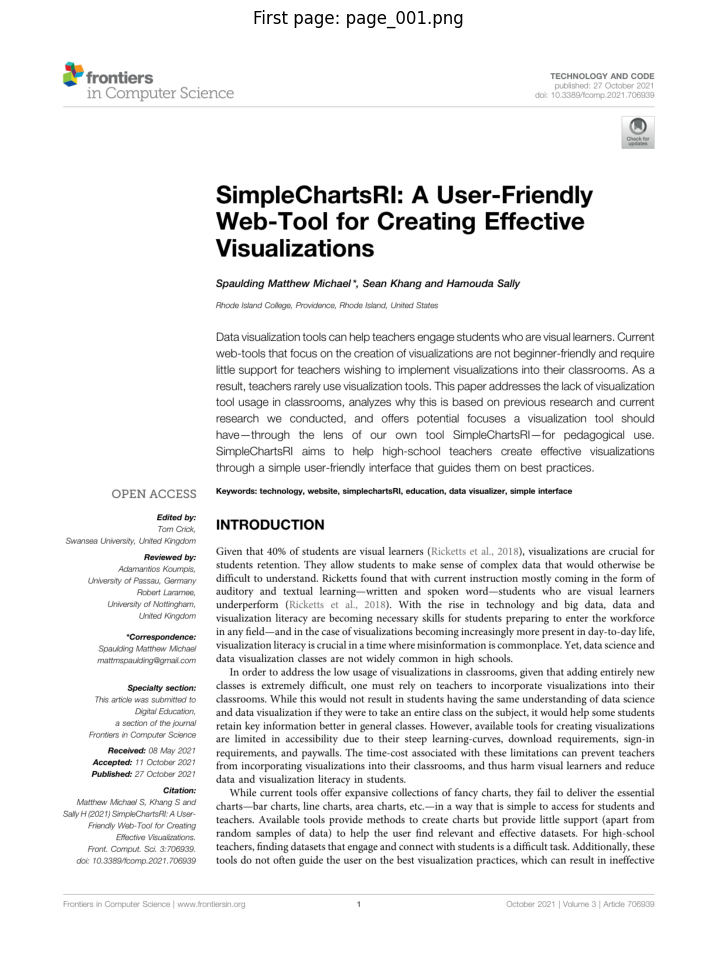

In [6]:
from pathlib import Path
import shutil, json, zipfile
import fitz  # PyMuPDF
from PIL import Image
import matplotlib.pyplot as plt

ROOT = Path("/content/chart_demo")
OUT  = Path("/content/chart_demo_outputs")
PAGE_OUT_DIR = OUT / "pdf_pages"

# ── Pre-filled: download sample papers and locate weights ─────────────────
SAMPLE_PAPERS_DRIVE_ID = "1m4MgUIP93ds8Jr7lMyp6csSKPPneew5w"
SAMPLE_DIR = ROOT / "sample_papers"
SAMPLE_ZIP = Path("/content/sample_papers.zip")

if SAMPLE_DIR.exists(): shutil.rmtree(SAMPLE_DIR)
SAMPLE_DIR.mkdir(parents=True, exist_ok=True)
if SAMPLE_ZIP.exists(): SAMPLE_ZIP.unlink()
!gdown "$SAMPLE_PAPERS_DRIVE_ID" -O "$SAMPLE_ZIP"

with zipfile.ZipFile(SAMPLE_ZIP, "r") as z:
    z.extractall(SAMPLE_DIR)

samples = sorted(SAMPLE_DIR.rglob("*.pdf"))[:6]
assert samples, "No PDFs found."
PDF_PATH = samples[0]
print(f"Using: {PDF_PATH.name}")

DEMO_ROOT = next((p for p in ROOT.iterdir() if p.is_dir() and (p/"weights").exists()), ROOT)
required_weights = {
    "chart_detector":  "chart_detector_v3.pt",
    "plot_classifier": "Plot_Classifier_new_latest.pt",
    "bar_detection":   "Bar_Detection_Yolo_v4.pt",
    "line_plot_area":  "plot_area_detector_line_v1.pt",
    "line_embed":      "best_line_embed_instance_v1.pt",
}
FOUND = {k: str(list(DEMO_ROOT.rglob(v))[0]) for k, v in required_weights.items() if list(DEMO_ROOT.rglob(v))}
OUT.mkdir(parents=True, exist_ok=True)
PATHS = {"demo_root": str(DEMO_ROOT), "out": str(OUT), "sample_pdf": str(PDF_PATH), **FOUND}
with open(OUT / "demo_paths.json", "w") as f:
    json.dump(PATHS, f, indent=2)
print("Weights found:", list(FOUND.keys()))

# ── STEP 1: Rasterize PDF pages to PNG images ─────────────────────────────
# Convert every page of PDF_PATH to a PNG and save to PAGE_OUT_DIR.
# Use PAGE_ZOOM (from PARAMS) to control resolution.

if PAGE_OUT_DIR.exists(): shutil.rmtree(PAGE_OUT_DIR)
PAGE_OUT_DIR.mkdir(parents=True, exist_ok=True)

# YOUR CODE HERE:


# ── Show first page ───────────────────────────────────────────────────────
page_pngs = sorted(PAGE_OUT_DIR.glob("page_*.png"))
plt.figure(figsize=(9, 12))
plt.imshow(Image.open(page_pngs[0]).convert("RGB"))
plt.axis("off"); plt.title(page_pngs[0].name); plt.show()


## STEP 5 — Detect chart regions on every page

Runs `chart_detector_v3.pt` (YOLO) on every page PNG. Saves:
- Each detected chart as a cropped PNG → `chart_demo_outputs/chart_crops/`
- Per-page overlay showing detections → `chart_demo_outputs/page_chart_detection_overlays/`
- Metadata CSV with bbox, page number, plot-on-page index

# ── Experiment: detection count vs confidence threshold ─────────────────────
import matplotlib.pyplot as plt

_thresholds = [0.10, 0.25, 0.40, 0.55, 0.70]
_counts = []
for _c in _thresholds:
    _n = sum(
        len(chart_model.predict(str(p), conf=_c, iou=DETECT_IOU, verbose=False)[0].boxes or [])
        for p in sorted(PAGE_OUT_DIR.glob("page_*.png"))
    )
    _counts.append(_n)

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(_thresholds, _counts, width=0.09, color="#4C72B0", edgecolor="black")
ax.axvline(DETECT_CONF, color="red", linestyle="--", linewidth=2,
           label=f"Your DETECT_CONF = {DETECT_CONF}")
for x, y in zip(_thresholds, _counts):
    ax.text(x, y + 0.2, str(y), ha="center", fontsize=10)
ax.set_xlabel("Confidence Threshold")
ax.set_ylabel("Charts Detected")
ax.set_title("Detection Count vs. Confidence Threshold")
ax.legend()
plt.tight_layout()
plt.show()
print(f"At DETECT_CONF={DETECT_CONF}: {len(df)} charts saved to {CHART_CROP_DIR}")


In [7]:
from pathlib import Path
import cv2, json, shutil
import pandas as pd
from ultralytics import YOLO
from IPython.display import display

OUT = Path("/content/chart_demo_outputs")
PAGE_OUT_DIR   = OUT / "pdf_pages"
CHART_CROP_DIR = OUT / "chart_crops"
DETECT_VIS_DIR = OUT / "page_chart_detection_overlays"
META_CSV = OUT / "chart_crops_metadata.csv"

with open(OUT / "demo_paths.json") as f:
    PATHS = json.load(f)

for d in [CHART_CROP_DIR, DETECT_VIS_DIR]:
    if d.exists(): shutil.rmtree(d)
    d.mkdir(parents=True, exist_ok=True)

# ── STEP 2: Detect charts, crop, and save ────────────────────────────────
# For each page PNG, run the chart detector (PATHS["chart_detector"]).
# Crop each detection (add CROP_PAD padding), save to CHART_CROP_DIR.
# Collect metadata into `records` — each dict must contain:
#   page_number, plot_number_on_page, global_plot_id,
#   crop_filename, crop_path, bbox_page_xyxy, detector_confidence

records = []

# YOUR CODE HERE:


# ── Save and display ──────────────────────────────────────────────────────
df = pd.DataFrame(records)
df.to_csv(META_CSV, index=False)
print(f"\n✅ {len(records)} crops saved → {CHART_CROP_DIR}")
display(df.head(15))


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Page 001: 0 chart(s)
Page 002: 0 chart(s)
Page 003: 4 chart(s)
Page 004: 0 chart(s)
Page 005: 4 chart(s)
Page 006: 2 chart(s)
Page 007: 3 chart(s)
Page 008: 0 chart(s)

✅ 13 chart crops saved to: /content/chart_demo_outputs/chart_crops


,page_number,plot_number_on_page,global_plot_id,crop_filename,crop_path,bbox_page_xyxy,detector_confidence
0,3,1,1,page_003_plot_01.png,/content/chart_demo_outputs/chart_crops/page_0...,"[681, 161, 1110, 397]",0.4754
1,3,2,2,page_003_plot_02.png,/content/chart_demo_outputs/chart_crops/page_0...,"[687, 187, 888, 379]",0.3647
2,3,3,3,page_003_plot_03.png,/content/chart_demo_outputs/chart_crops/page_0...,"[659, 443, 1112, 724]",0.5427
3,3,4,4,page_003_plot_04.png,/content/chart_demo_outputs/chart_crops/page_0...,"[668, 509, 867, 698]",0.3064
4,5,1,5,page_005_plot_01.png,/content/chart_demo_outputs/chart_crops/page_0...,"[81, 127, 588, 367]",0.3297
5,5,2,6,page_005_plot_02.png,/content/chart_demo_outputs/chart_crops/page_0...,"[516, 1092, 646, 1196]",0.3961
6,5,3,7,page_005_plot_03.png,/content/chart_demo_outputs/chart_crops/page_0...,"[635, 1096, 766, 1243]",0.3280
7,5,4,8,page_005_plot_04.png,/content/chart_demo_outputs/chart_crops/page_0...,"[695, 1241, 830, 1393]",0.3483
8,6,1,9,page_006_plot_01.png,/content/chart_demo_outputs/chart_crops/page_0...,"[475, 135, 904, 402]",0.6059
9,6,2,10,page_006_plot_02.png,/content/chart_demo_outputs/chart_crops/page_0...,"[595, 518, 1128, 874]",0.8251


## STEP 6 — Classify each chart's type

Runs `Plot_Classifier_new_latest.pt` on every chart crop to predict bar / line / pie / scatter / other.

Classifier classes: {0: 'bar', 1: 'line', 2: 'other', 3: 'pie', 4: 'scatter'}

=== Chart type counts ===


,pred_chart_type,count
0,bar,2
1,line,4
2,other,3
3,pie,4



=== All charts ===


,global_plot_id,page_number,plot_number_on_page,crop_filename,pred_chart_type,pred_chart_type_confidence
0,1,3,1,page_003_plot_01.png,pie,0.8896
1,2,3,2,page_003_plot_02.png,pie,0.9999
2,3,3,3,page_003_plot_03.png,pie,0.9611
3,4,3,4,page_003_plot_04.png,pie,1.0000
4,5,5,1,page_005_plot_01.png,other,0.9450
5,6,5,2,page_005_plot_02.png,bar,0.9927
6,7,5,3,page_005_plot_03.png,line,0.5106
7,8,5,4,page_005_plot_04.png,other,0.9274
8,9,6,1,page_006_plot_01.png,line,0.9879
9,10,6,2,page_006_plot_02.png,line,0.9993


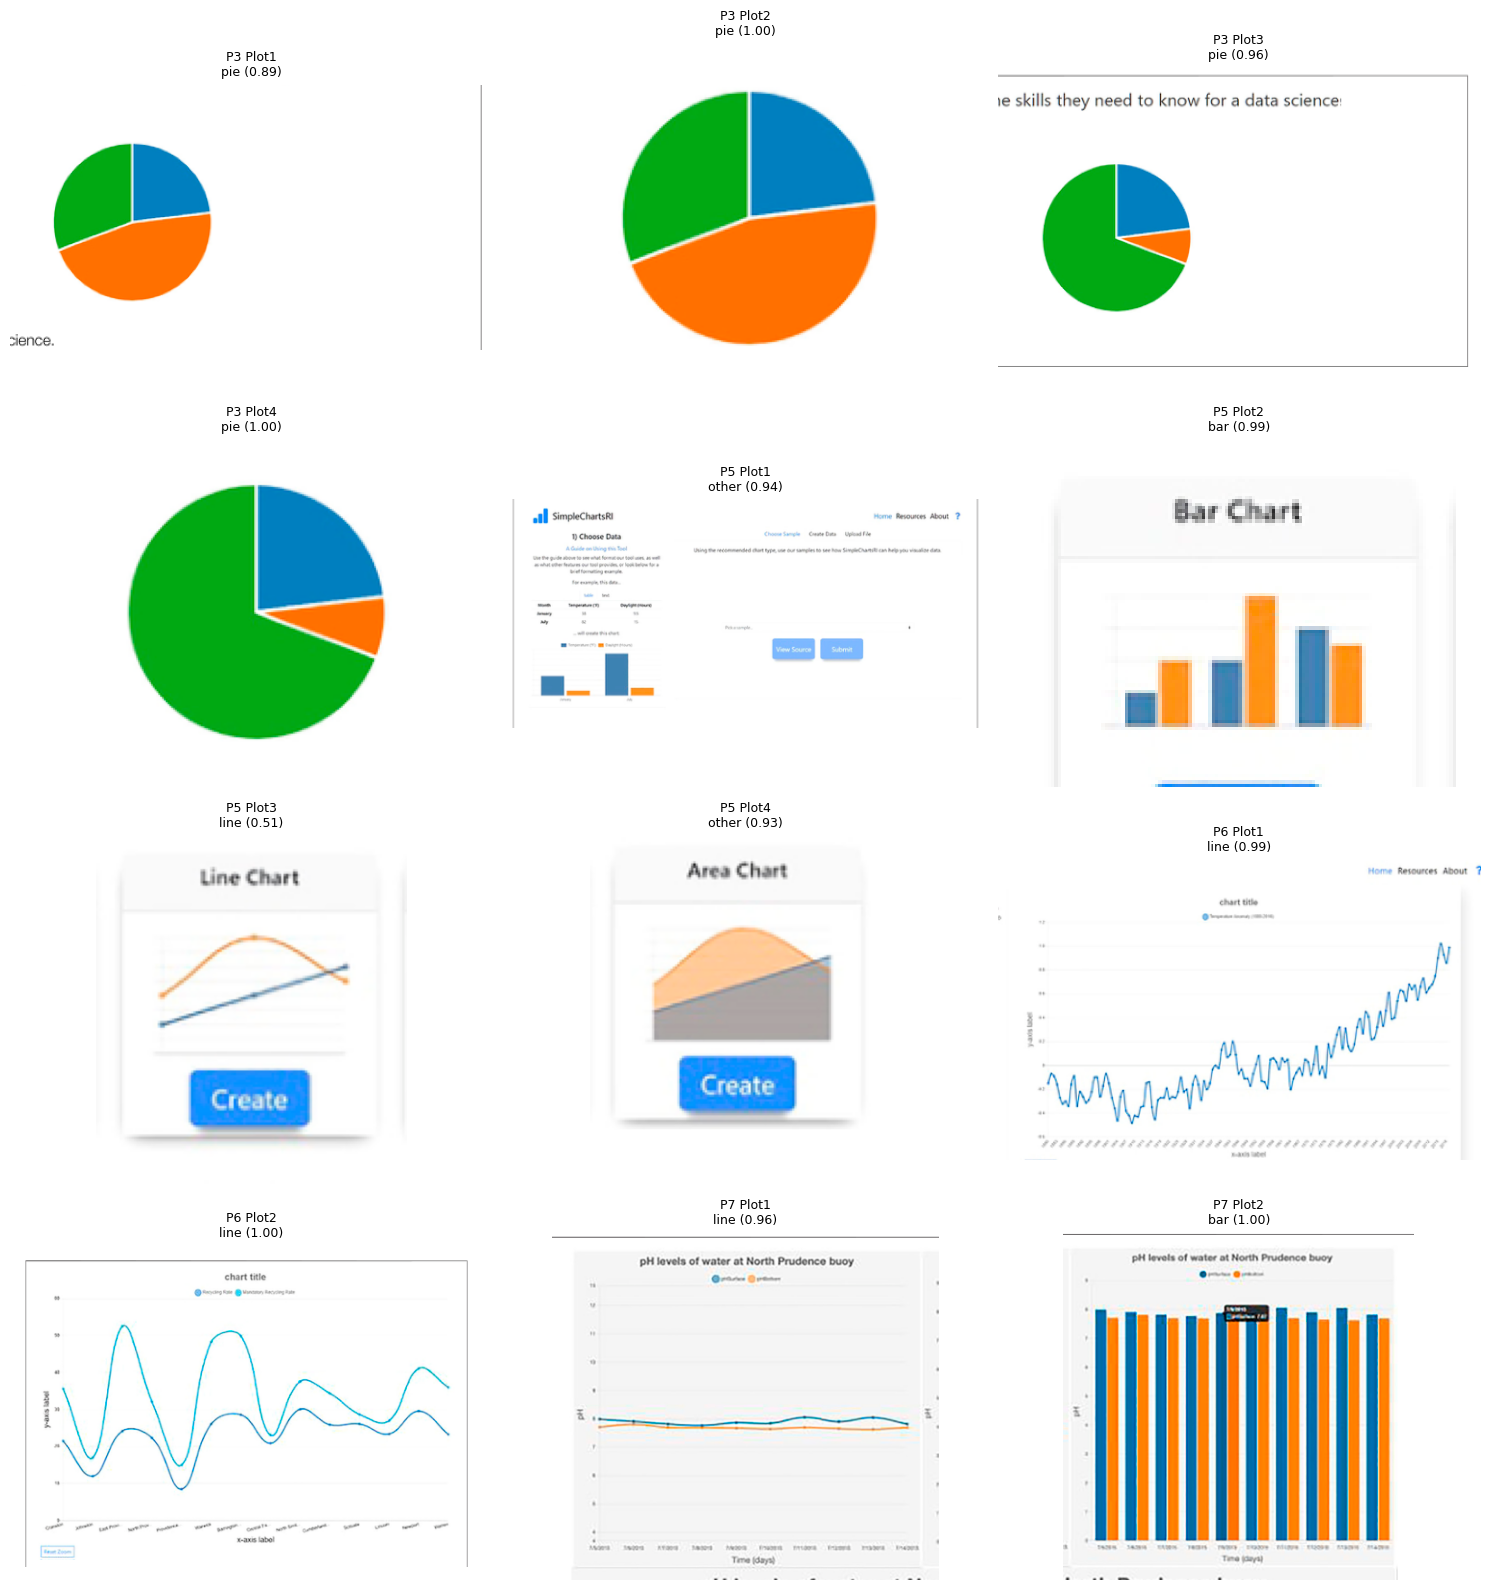

In [8]:
from pathlib import Path
import json, math
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
from IPython.display import display

OUT = Path("/content/chart_demo_outputs")
META_CSV       = OUT / "chart_crops_metadata.csv"
CLASSIFIED_CSV = OUT / "chart_crops_classified_metadata.csv"

with open(OUT / "demo_paths.json") as f:
    PATHS = json.load(f)

# ── STEP 3: Classify each crop as bar / line / pie / scatter ─────────────
# Load PATHS["plot_classifier"]. For each crop in META_CSV, predict the
# chart type. If confidence < CLASSIFIER_MIN_CONF, label it "low_conf".
# Add "pred_chart_type" and "pred_chart_type_confidence" to each row.

df = pd.read_csv(META_CSV)
pred_rows = []

# YOUR CODE HERE:


# ── Gallery preview ───────────────────────────────────────────────────────
classified_df = pd.DataFrame(pred_rows)
classified_df.to_csv(CLASSIFIED_CSV, index=False)
print("\n=== Chart type counts ===")
display(classified_df.groupby("pred_chart_type").size().reset_index(name="count"))

MAX_SHOW = min(12, len(classified_df))
cols = 3; rows = math.ceil(MAX_SHOW / cols)
plt.figure(figsize=(cols*5, rows*4))
for i in range(MAX_SHOW):
    row = classified_df.iloc[i]
    plt.subplot(rows, cols, i+1)
    plt.imshow(Image.open(row["crop_path"]).convert("RGB")); plt.axis("off")
    plt.title(f"{row['pred_chart_type']} ({row['pred_chart_type_confidence']:.2f})", fontsize=9)
plt.tight_layout(); plt.show()


## STEP 7 — OCR helpers (PaddleOCR already loaded in STEP 1)

Defines:
- `run_paddle_ocr(path)` → list of text regions with bbox & confidence
- `featurize_box(box, W, H)` → adds position bands, numeric/percent flags, rotation
- role lists for bar / line / pie / scatter charts

The `ocr` PaddleOCR object was already created in STEP 1, Cell 4.

In [9]:
import math, re, json
from pathlib import Path
import numpy as np
from PIL import Image

# (The `ocr` PaddleOCR object was created in STEP 1 — do not reload it here.)

NUMERIC_RE  = re.compile(r"^-?\d+(\.\d+)?$")
PERCENT_RE  = re.compile(r"^-?\d+(\.\d+)?%$")
CURRENCY_RE = re.compile(r"[\$€£¥₹]")
SUFFIX_RE   = re.compile(r"^-?\d+(\.\d+)?\s*[kmbKMB]$")
YEAR_RE     = re.compile(r"^'?\d{2,4}$")

# ── Pre-filled: OCR runner ────────────────────────────────────────────────
def run_paddle_ocr(image_path):
    "Return list of {text, bbox, poly, confidence, angle}."
    result = ocr.predict(input=str(image_path))
    boxes = []
    for res in result:
        try:
            texts  = res["rec_texts"]
            scores = res["rec_scores"]
            polys  = res["rec_polys"]
        except (KeyError, TypeError):
            data = res.json.get("res", res.json) if hasattr(res, "json") else res
            texts, scores, polys = data["rec_texts"], data["rec_scores"], data["rec_polys"]

        for text, score, poly in zip(texts, scores, polys):
            if str(text).strip() == "":
                continue
            poly_arr = np.array(poly, dtype=float)
            x1, y1 = poly_arr.min(axis=0)
            x2, y2 = poly_arr.max(axis=0)
            dx = poly_arr[1][0] - poly_arr[0][0]
            dy = poly_arr[1][1] - poly_arr[0][1]
            angle = math.degrees(math.atan2(dy, dx))
            if float(score) < OCR_MIN_CONF:
                continue
            boxes.append({
                "text": str(text).strip(),
                "bbox": [int(x1), int(y1), int(x2), int(y2)],
                "poly": poly_arr.tolist(),
                "confidence": float(score),
                "angle": float(angle),
            })
    return boxes

# ── Pre-filled: per-box feature extraction ───────────────────────────────
def featurize_box(b, W, H):
    t = b["text"]
    cx = (b["bbox"][0] + b["bbox"][2]) / 2
    cy = (b["bbox"][1] + b["bbox"][3]) / 2
    bw = b["bbox"][2] - b["bbox"][0]
    bh = b["bbox"][3] - b["bbox"][1]

    yfrac = cy / max(H, 1)
    xfrac = cx / max(W, 1)
    y_band = ("very_top" if yfrac<0.12 else "top" if yfrac<0.30 else
              "middle" if yfrac<0.70 else "bottom" if yfrac<0.88 else "very_bottom")
    x_band = ("very_left" if xfrac<0.15 else "left" if xfrac<0.35 else
              "center" if xfrac<0.65 else "right" if xfrac<0.85 else "very_right")

    is_rotated = (30 < abs(b["angle"]) < 150) or (bh > bw*1.5 and len(t) > 3)
    clean_num = t.replace(",", "").replace("\u20b9", "").replace("$", "")

    b["features"] = {
        "is_numeric": bool(NUMERIC_RE.match(clean_num) or SUFFIX_RE.match(clean_num)),
        "is_percent": bool(PERCENT_RE.match(clean_num)),
        "is_year":    bool(YEAR_RE.match(t)),
        "is_currency":bool(CURRENCY_RE.search(t)),
        "word_count": len(t.split()),
        "char_count": len(t),
        "y_band": y_band, "x_band": x_band,
        "is_rotated": is_rotated,
    }
    return b

ROLES_AXIS = ["title","subtitle","x_tick","y_tick","x_axis_title","y_axis_title",
              "data_label","legend","caption","other"]
ROLES_PIE  = ["title","subtitle","slice_label","slice_value","legend","caption","other"]

def roles_for_type(chart_type):
    return ROLES_PIE if chart_type == "pie" else ROLES_AXIS

print("✅ OCR + featurize helpers ready")
print("   Test: boxes = run_paddle_ocr('/path/to/crop.png')")


✅ OCR + helpers defined


## STEP 8 — Load Qwen2.5-VL (one clean copy, fully on GPU)

Loads **Qwen/Qwen2.5-VL-7B-Instruct** with `device_map="cuda:0"` so the whole model stays on GPU.
(Using `device_map="auto"` is risky — if VRAM is tight it silently CPU-offloads layers,
making each inference 20-50x slower.)

If you have a T4 (15 GB) and hit OOM, swap the model name to `Qwen/Qwen2.5-VL-3B-Instruct`.

In [10]:
!pip install -U "bitsandbytes>=0.46.1" accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 46.5 MB/s  0:00:01


In [11]:
# ============================================================
# STEP 8: Qwen2.5-VL — workshop default: 3B 4-bit (~2 GB download)
# Post-workshop: set FORCE_3B=False on an L4/A100 to switch to 7B bf16
# ============================================================

import os, gc, time

# Must be set before heavy CUDA allocations
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch

# Clean any old models if cell is re-run
for name in [
    "qwen_model", "qwen_processor",
    "chart_model", "clf_model",
    "bar_axis_model", "bar_det_model", "bar_yolo8_model",
    "line_axis_model", "line_plot_area_model",
]:
    if name in globals():
        print("Deleting:", name)
        del globals()[name]

gc.collect()
torch.cuda.empty_cache()

assert torch.cuda.is_available(), (
    "❌ No GPU detected. In Colab: Runtime → Change runtime type → GPU."
)

gpu_name = torch.cuda.get_device_name(0)
total_gb = torch.cuda.get_device_properties(0).total_memory / 1e9

print(f"GPU: {gpu_name} ({total_gb:.1f} GB)")
!nvidia-smi

from transformers import (
    Qwen2_5_VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig,
)
from qwen_vl_utils import process_vision_info

# For live demo, safer to keep 3B even on L4.
FORCE_3B = True

if FORCE_3B or total_gb < 20:
    MODEL_NAME = "Qwen/Qwen2.5-VL-3B-Instruct"
    USE_4BIT = True
    print("→ Using Qwen 3B in 4-bit mode")
else:
    MODEL_NAME = "Qwen/Qwen2.5-VL-7B-Instruct"
    USE_4BIT = False
    print("→ Using Qwen 7B bf16")

print("Loading:", MODEL_NAME)

if USE_4BIT:
    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
    )

    qwen_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        MODEL_NAME,
        quantization_config=quant_config,
        device_map="auto",
        low_cpu_mem_usage=True,
    )
else:
    qwen_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        MODEL_NAME,
        torch_dtype=torch.bfloat16,
        device_map="auto",
        low_cpu_mem_usage=True,
    )

# IMPORTANT:
# use_fast=False avoids the Qwen processor fast-import error.
qwen_processor = AutoProcessor.from_pretrained(
    MODEL_NAME,
    use_fast=False,
    min_pixels=256 * 28 * 28,
    max_pixels=640 * 28 * 28,
)

qwen_model.eval()

print("✅ Qwen model loaded:", MODEL_NAME)
print("Main device:", next(qwen_model.parameters()).device)
!nvidia-smi


def qwen_infer(image, prompt, max_new_tokens=256):
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": prompt},
        ],
    }]

    text = qwen_processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = qwen_processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    ).to("cuda")

    with torch.inference_mode():
        gen = qwen_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            num_beams=1,
            use_cache=True,
        )

    trimmed = gen[0][inputs.input_ids.shape[1]:]
    return qwen_processor.decode(trimmed, skip_special_tokens=True)


# Warmup test
from PIL import Image

t0 = time.time()

reply = qwen_infer(
    Image.new("RGB", (384, 384), "white"),
    "Reply with one word: ok.",
    max_new_tokens=5,
)

print("Warmup reply:", reply)
print(f"Warmup time: {time.time() - t0:.2f}s")

Deleting: chart_model
Deleting: clf_model
GPU: Tesla T4 (15.6 GB)
Mon May 25 10:14:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P0             27W /   70W |     199MiB /  15360MiB |      0%      Default |
|                                         |                        |      

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Qwen model loaded: Qwen/Qwen2.5-VL-3B-Instruct
Main device: cuda:0
Mon May 25 10:16:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   59C    P0             29W /   70W |    6455MiB /  15360MiB |      0%      Default |
|                                         |                        |   

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Warmup reply: ok
Warmup time: 3.73s


## STEP 9 — Define the role classifier (`classify_roles_fast`)

Sends the chart image + a compact list of OCR regions to Qwen and asks it to label each region
as `title`, `x_tick`, `y_tick`, `data_label`, etc. Returns the boxes annotated with `role`.

In [12]:
import re, json
from PIL import Image

FAST_ROLE_PROMPT_TEMPLATE = """Classify OCR text regions in this {chart_type} chart.

Valid roles:
{role_list}

OCR regions:
{regions_block}

Rules:
top main text=title; left stacked numbers=y_tick; bottom labels=x_tick;
rotated left text=y_axis_title; bottom axis name=x_axis_title;
numbers on bars/points=data_label; legend entries=legend;
source/note/footer=caption; unclear=other.

Return ONLY compact JSON:
[{{"id":0,"role":"title","confidence":"high"}}]
One item per OCR region."""

# ── Pre-filled: prompt builder ────────────────────────────────────────────
def build_regions_block_fast(boxes, max_boxes=MAX_OCR_BOXES):
    lines = []
    for i, b in enumerate(boxes[:max_boxes]):
        f = b["features"]
        t = b["text"]
        if len(t) > 50:
            t = t[:50] + "..."
        tags = []
        if f["is_numeric"]: tags.append("numeric")
        if f["is_percent"]: tags.append("percent")
        if f["is_year"]:    tags.append("year")
        if f["is_rotated"]: tags.append("rotated")
        tag_str = ",".join(tags) if tags else "text"
        lines.append(f'id={i} text="{t}" pos=({f["x_band"]},{f["y_band"]}) type={tag_str}')
    return "\n".join(lines)

# ── Pre-filled: Qwen role classifier ─────────────────────────────────────
def classify_roles_fast(image_path, boxes, chart_type):
    if not boxes:
        return []
    img = Image.open(image_path).convert("RGB")
    if max(img.size) > 640:
        img.thumbnail((640, 640), Image.LANCZOS)

    prompt = FAST_ROLE_PROMPT_TEMPLATE.format(
        chart_type=chart_type,
        role_list=", ".join(roles_for_type(chart_type)),
        regions_block=build_regions_block_fast(boxes),
    )
    raw = qwen_infer(img, prompt, max_new_tokens=256)

    parsed = []
    try:
        m = re.search(r"\[.*\]", raw, re.DOTALL)
        if m:
            parsed = json.loads(m.group())
    except Exception as e:
        print("  JSON parse failed:", e)

    id_to_role = {}
    for item in parsed:
        if isinstance(item, dict) and "id" in item:
            id_to_role[int(item["id"])] = (
                item.get("role", "other"),
                item.get("confidence", "low"),
            )

    allowed = set(roles_for_type(chart_type))
    for i, b in enumerate(boxes):
        role, conf = id_to_role.get(i, ("other", "low"))
        if role not in allowed:
            role = "other"
        b["role"] = role
        b["role_confidence"] = conf
    return boxes

print("✅ classify_roles_fast ready")


✅ classify_roles_fast defined


## STEP 10 — Load the bar & line YOLO detectors

Three small YOLO weights:
- `Bar_Detection_Yolo_v4.pt` — bar bounding boxes
- `plot_area_detector_line_v1.pt` — plot region for line charts
- `axis_finder.pt` — axis regions for line charts

These are quick (a few hundred MB each) and run on GPU.

In [13]:
from pathlib import Path
import json
from ultralytics import YOLO

with open("/content/chart_demo_outputs/demo_paths.json") as f:
    PATHS = json.load(f)

print("Loading bar detector...")
bar_det_model = YOLO(PATHS["bar_detection"])
print("  \u2713", PATHS["bar_detection"])

print("Loading line plot-area detector...")
line_plot_area_model = YOLO(PATHS["line_plot_area"])
print("  \u2713", PATHS["line_plot_area"])

print("Loading line axis detector...")
line_axis_model = YOLO(PATHS["line_axis"])
print("  \u2713", PATHS["line_axis"])

print("\n\u2705 All YOLO bar/line models loaded")

Loading bar detector...
  ✓ /content/chart_demo/weights/bar/Bar_Detection_Yolo_v4.pt
Loading line plot-area detector...
  ✓ /content/chart_demo/weights/line/plot_area_detector_line_v1.pt
Loading line axis detector...
  ✓ /content/chart_demo/weights/line/axis_finder.pt

✅ All YOLO bar/line models loaded


## STEP 11 — Combined bar + line demo

For every detected bar or line chart:

1. PaddleOCR finds text regions
2. Qwen labels each region (title, ticks, axis titles, data labels, ...)
3. Per-type YOLO runs:
   - **Bar charts** → `Bar_Detection_Yolo_v4` (bars)
   - **Line charts** → plot-area box + axis boxes
4. A combined overlay PNG is saved + a structured JSON entry is appended

Output:
- `bar_line_demo_outputs/reports/*.png` — one image per chart
- `bar_line_demo_outputs/bar_line_demo_results.json` — all results

Using bar weight: /content/chart_demo/weights/bar/Bar_Detection_Yolo_v4.pt
Using line plot-area weight: /content/chart_demo/weights/line/plot_area_detector_line_v1.pt
Using line axis weight: /content/chart_demo/weights/line/axis_finder.pt
Using line UNet/embed weight: /content/chart_demo/weights/line/best_line_embed_instance_v1.pt
Loaded line_unet_model on cuda
Missing: 0 Unexpected: 0
6 bar+line crops (2 bar, 4 line)


,global_plot_id,page_number,plot_number_on_page,crop_filename,pred_chart_type,pred_chart_type_confidence,normalized_chart_type
5,6,5,2,page_005_plot_02.png,bar,0.9927,bar
6,7,5,3,page_005_plot_03.png,line,0.5106,line
8,9,6,1,page_006_plot_01.png,line,0.9879,line
9,10,6,2,page_006_plot_02.png,line,0.9993,line
10,11,7,1,page_007_plot_01.png,line,0.9571,line
11,12,7,2,page_007_plot_02.png,bar,1.0000,bar


final bar+line:   0%|          | 0/6 [00:00<?, ?it/s]


--- page_005_plot_02.png [bar] ---
  OCR: 1 regions
  Qwen: roles assigned
  BAR YOLO: 7 bars


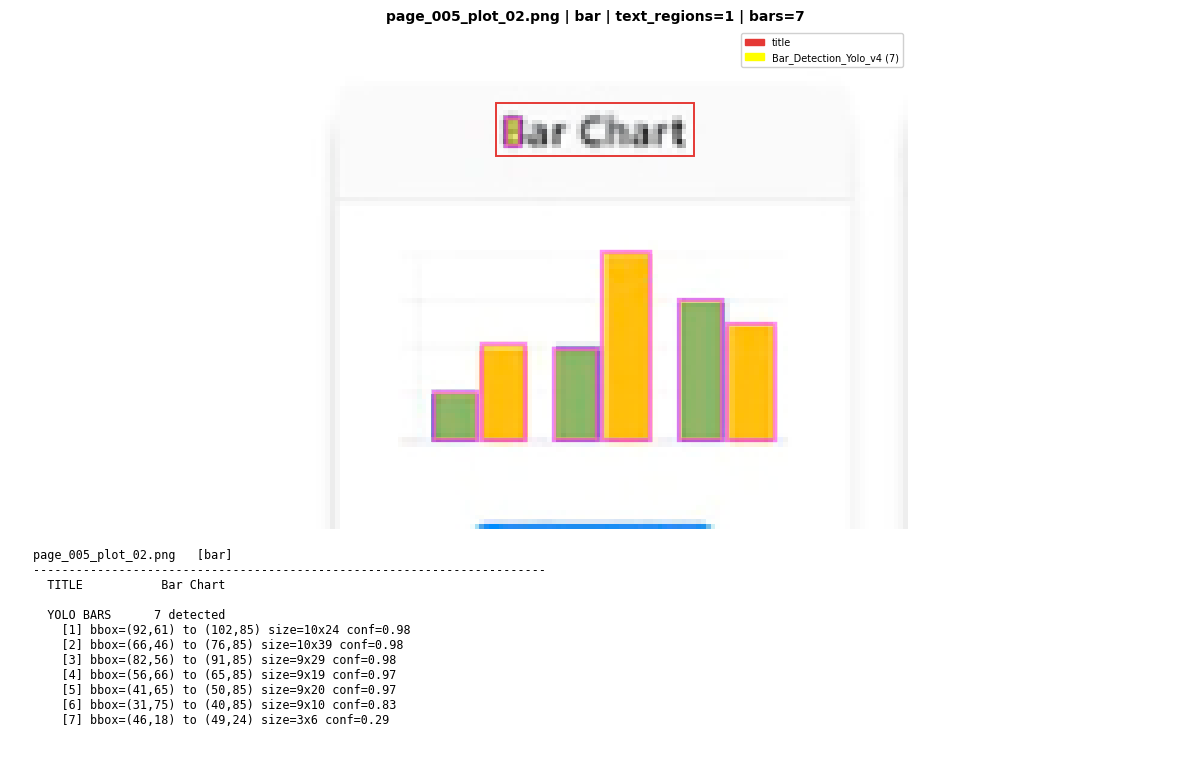

final bar+line:  17%|█▋        | 1/6 [00:13<01:07, 13.51s/it]

  saved page_005_plot_02_final_demo.png

--- page_005_plot_03.png [line] ---
  OCR: 2 regions
  Qwen: roles assigned
  LINE: plot_area=1, line_pixels=773, series_parts=1, axis_raw_hidden=172


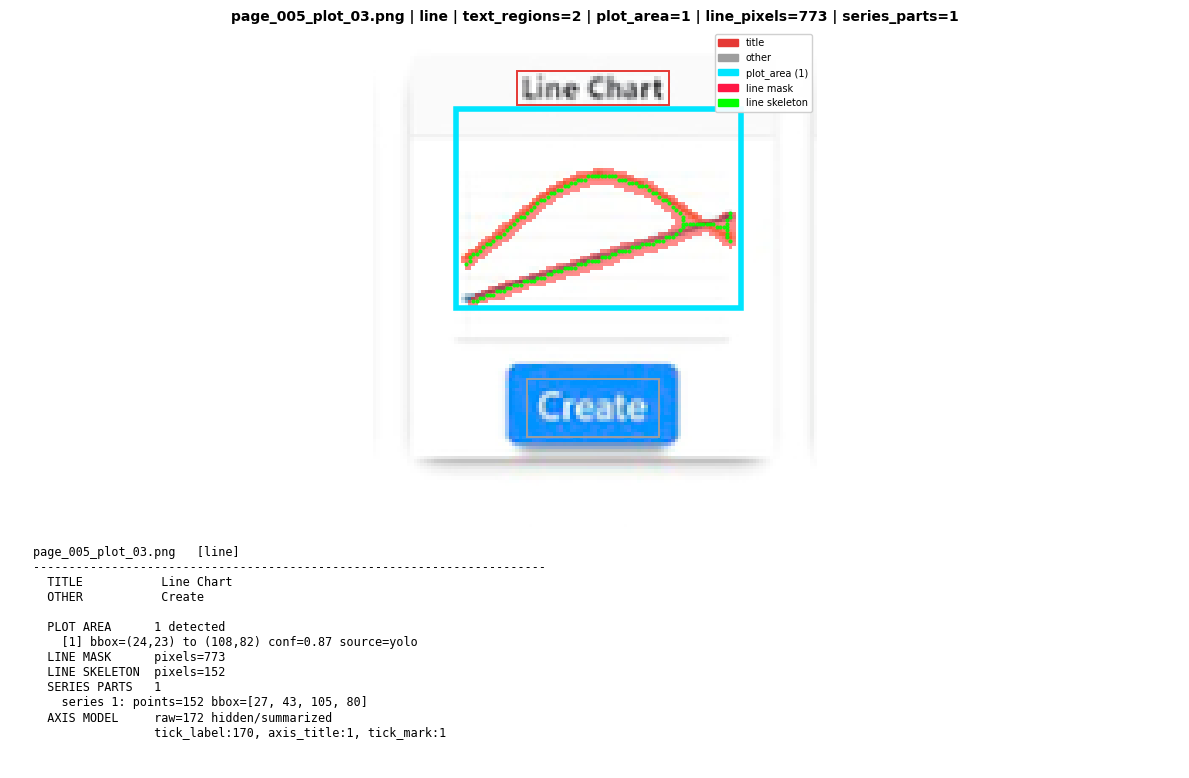

final bar+line:  33%|███▎      | 2/6 [00:25<00:49, 12.40s/it]

  saved page_005_plot_03_final_demo.png

--- page_006_plot_01.png [line] ---
  OCR: 4 regions
  Qwen: roles assigned
  LINE: plot_area=1, line_pixels=7869, series_parts=3, axis_raw_hidden=124


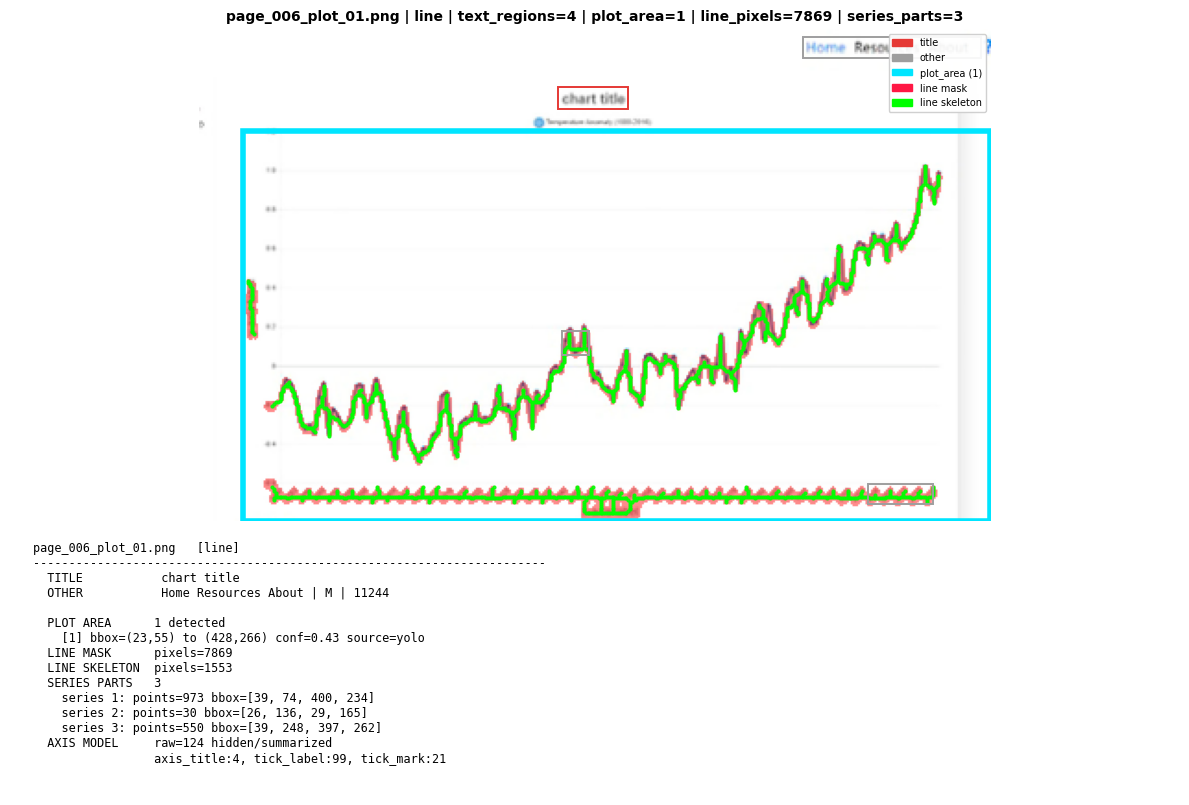

final bar+line:  50%|█████     | 3/6 [00:40<00:41, 13.94s/it]

  saved page_006_plot_01_final_demo.png

--- page_006_plot_02.png [line] ---
  OCR: 5 regions
  Qwen: roles assigned
  LINE: plot_area=1, line_pixels=8611, series_parts=19, axis_raw_hidden=161


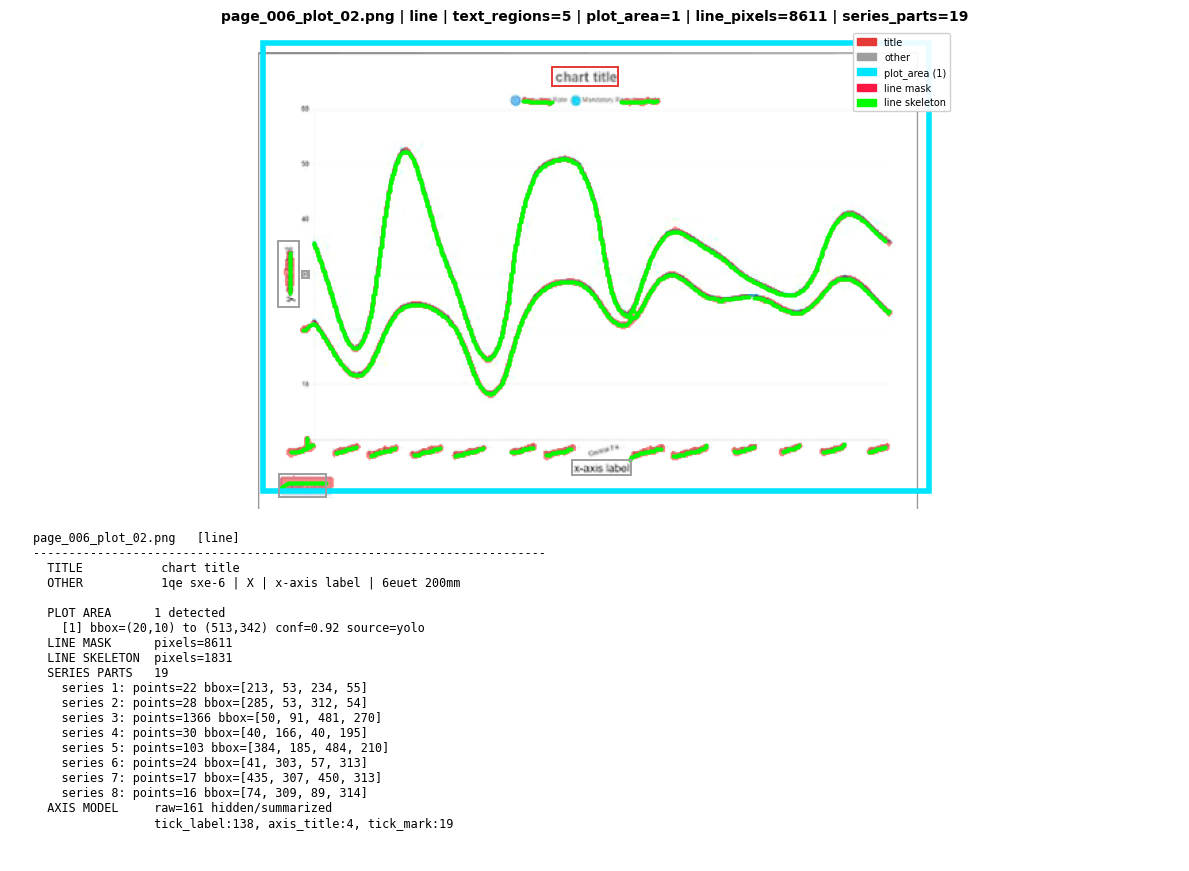

final bar+line:  67%|██████▋   | 4/6 [00:49<00:24, 12.01s/it]

  saved page_006_plot_02_final_demo.png

--- page_007_plot_01.png [line] ---
  OCR: 7 regions
  Qwen: roles assigned
  LINE: plot_area=1, line_pixels=1448, series_parts=5, axis_raw_hidden=300


/tmp/ipykernel_1598/281651776.py:685: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-5929}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_1598/281651776.py:686: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-5929}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="white")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-5929}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


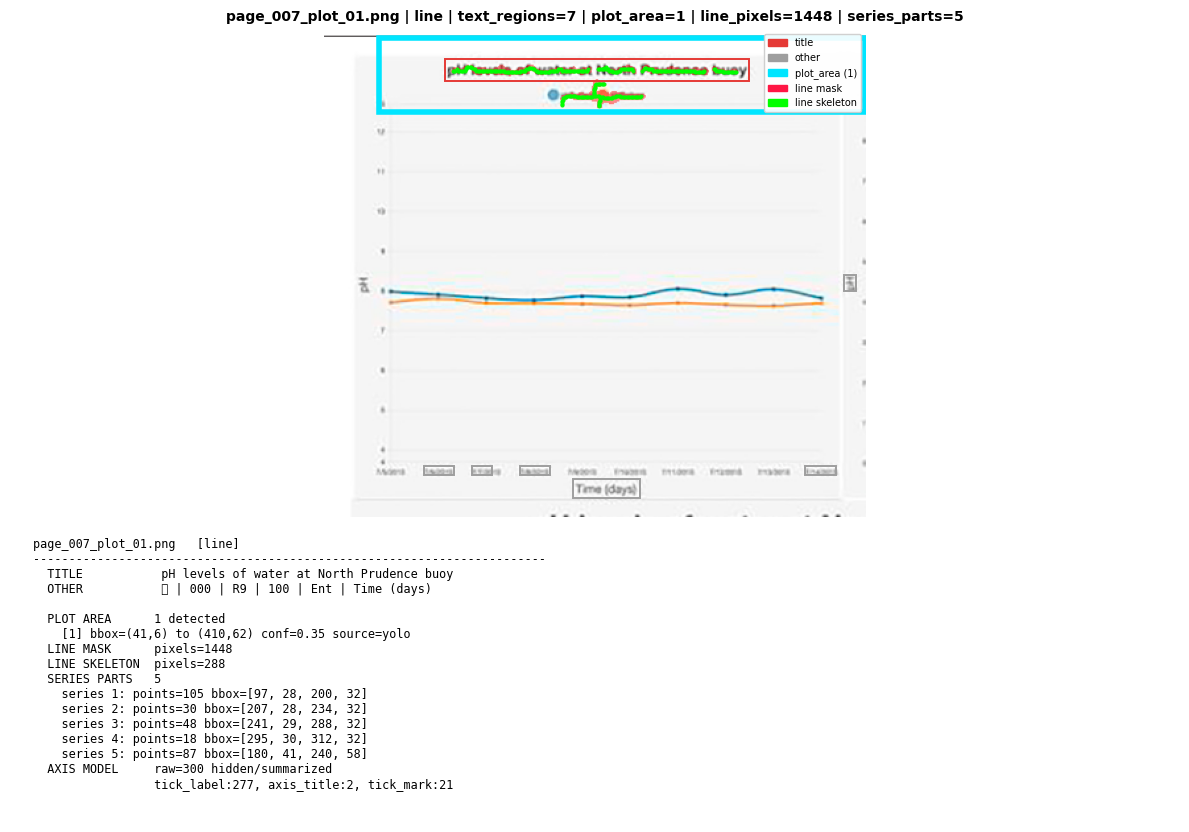

final bar+line:  83%|████████▎ | 5/6 [00:58<00:10, 10.90s/it]

  saved page_007_plot_01_final_demo.png

--- page_007_plot_02.png [bar] ---
  OCR: 2 regions
  Qwen: roles assigned
  BAR YOLO: 20 bars


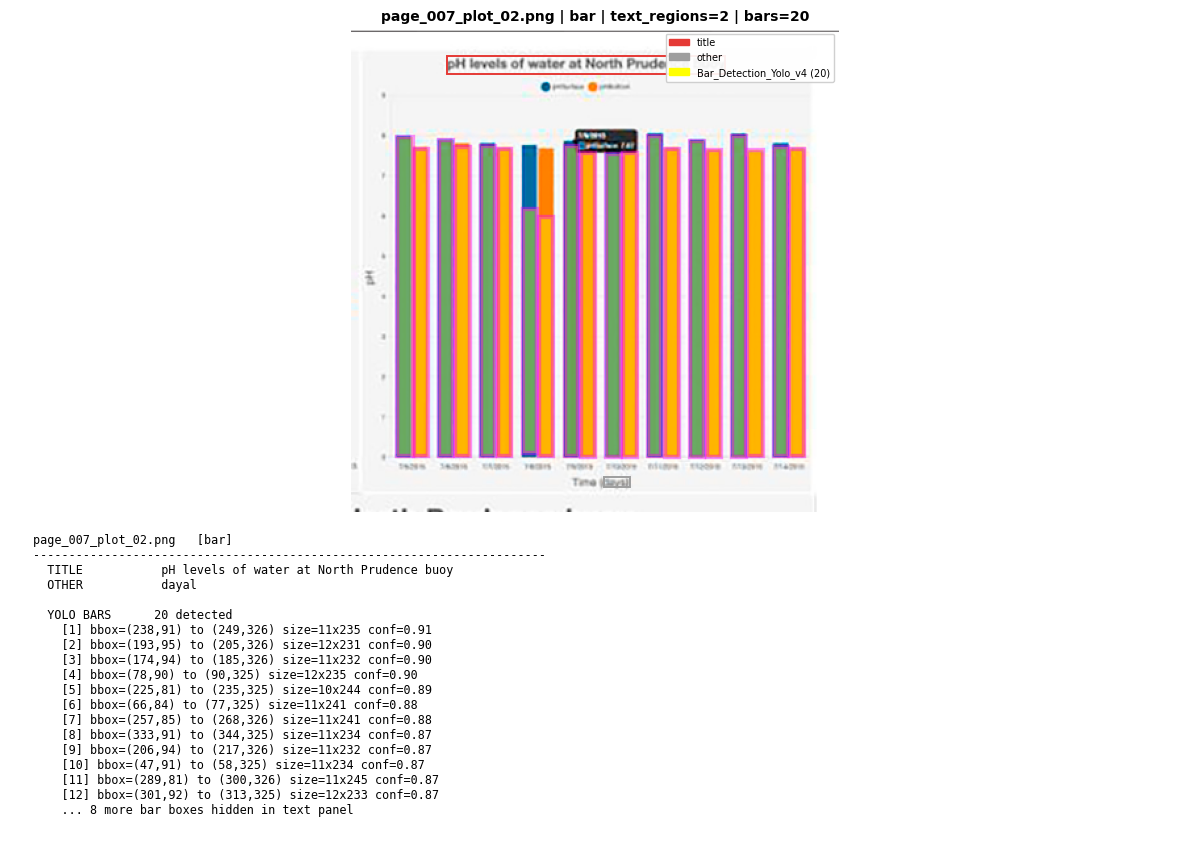

final bar+line: 100%|██████████| 6/6 [01:06<00:00, 11.02s/it]

  saved page_007_plot_02_final_demo.png

Demo complete
Clean JSON: /content/chart_demo_outputs/bar_line_demo_outputs_final/bar_line_demo_results_clean.json
Reports:    /content/chart_demo_outputs/bar_line_demo_outputs_final/reports
Processed: 6/6 (2 bar, 4 line)


In [14]:
# ============================================================
# STEP 6: Wire the full pipeline
# ============================================================
import math, json
from pathlib import Path
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import pandas as pd

OUT = Path("/content/chart_demo_outputs")
ROLE_VIS_DIR = OUT / "role_overlays"
ROLE_VIS_DIR.mkdir(parents=True, exist_ok=True)

classified_df = pd.read_csv(OUT / "chart_crops_classified_metadata.csv")
target_df = classified_df[classified_df["pred_chart_type"].isin(["bar", "line"])].copy()
print(f"Processing {len(target_df)} bar/line charts...")

ROLE_COLORS = {
    "title": (255,50,50), "x_tick": (50,180,50), "y_tick": (50,50,255),
    "x_axis_title": (200,100,0), "y_axis_title": (0,180,180),
    "data_label": (180,0,180), "legend": (180,180,0),
    "caption": (120,120,120), "other": (200,200,200),
}

# ── STEP 6: For each bar/line crop, run the full pipeline ─────────────────
# A. OCR: run_paddle_ocr(crop_path), then featurize_box(b, W, H) for each box.
# B. Roles: classify_roles_fast(crop_path, boxes, chart_type)
# C. Draw coloured bboxes (ROLE_COLORS) on the image and save to ROLE_VIS_DIR.
# D. Run the YOLO extractor: bar_det_model or line_plot_area_model.
#    Print how many detections were found.

saved_paths = []

for _, row in target_df.iterrows():
    crop_path  = Path(row["crop_path"])
    chart_type = row["pred_chart_type"]
    print(f"\n── {crop_path.name}  [{chart_type}] ──")

    # YOUR CODE HERE:


    saved_paths.append(ROLE_VIS_DIR / crop_path.name)

# ── Display saved overlays ────────────────────────────────────────────────
cols = 3
rows = math.ceil(len(saved_paths) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*4))
axes = axes.flatten()
for ax, p in zip(axes, saved_paths):
    if Path(p).exists(): ax.imshow(Image.open(p))
    ax.set_title(Path(p).name, fontsize=7); ax.axis("off")
for ax in axes[len(saved_paths):]: ax.axis("off")
plt.tight_layout(); plt.show()


## 🎉 Done

Output structure:

```
/content/chart_demo_outputs/
├── pdf_pages/                              ← rendered PDF pages
├── chart_crops/                            ← detected chart images
├── page_chart_detection_overlays/          ← page-level detection viz
├── chart_crops_classified_metadata.csv     ← per-chart type predictions
└── bar_line_demo_outputs/
    ├── reports/                            ← per-chart combined overlay
    └── bar_line_demo_results.json          ← structured results
```



**To switch to a sample paper:** edit `PDF_PATH` in Step 3 to one of the files under `/content/chart_demo/sample_papers/`.